# FairModelWrapper — bring your own neural network

The other models in this library — `FairLinear`, `FairKernelRidge`, `FairPCA`, `FairKernelPCA` — each hard-wire a specific predictor and bake the CKA fairness penalty directly into their training loops. That is perfect if you want the closed-form warm-starts and tight integration those models give you. It is a dead end the moment you need a non-linear predictor, a convolutional feature extractor, a transformer encoder, or anything at all that a specialised Keras-Tuner pipeline, a custom optimizer, or a pre-written training recipe already handles for you.

`FairModelWrapper` is the escape hatch. You write any `keras.Model` you like. You hand it to the wrapper. You call the same `compile` / `fit` you would have called anyway — and the CKA penalty rides along for the trip. Nothing else in your training stack has to change.

**What you will see in this notebook**

1. A synthetic regression problem engineered to *want* to rely on a sensitive attribute `q` — so the fairness penalty has something to push against.
2. A stock Keras MLP, wrapped unchanged, trained at four values of $\mu$.
3. Training loss curves, decomposed into the *task* term (what you asked the optimizer to minimise) and the *fairness* term (what the wrapper added on your behalf).
4. The fairness / accuracy trade-off curve — the classic plot that tells you how much accuracy you are spending per unit of fairness.
5. A one-line swap from CKA to HSIC as the dependence measure.
6. A 20-trial Keras-Tuner random search over the kernel bandwidths and learning rate — showing that $\mu$ is only one knob on a six-dimensional trade-off surface.

We care about the *story* these panels tell, not the raw numbers. Most panels are paired with a "what to notice" paragraph underneath so you can read the narrative at a glance without staring at axes.

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

from _style import SCATTER_KW, style_ax
from fairkl.metrics.cka import CKALoss, cka_rbf
from fairkl.metrics.hsic import HSICLoss
from fairkl.models import FairModelWrapper

## Synthetic data — a problem that *wants* to be unfair

We need a task where an off-the-shelf regressor would naturally lean on the sensitive attribute `q`. Otherwise the fairness penalty has nothing interesting to do, and the demonstration collapses.

The generating process is

$$
y \;=\; \tanh(x_1) \;+\; 0.5\, x_2 \;+\; 3\, q \;+\; \varepsilon,
$$

with three informative features $x_{1:3}$, a sensitive attribute $q$ that contributes *linearly and strongly* (coefficient 3, dominating the other effects), and a small amount of Gaussian noise. Crucially, we **concatenate `q` into the input `X`**: the network is allowed to see the sensitive attribute. That is the hard setting — the easy setting where you just drop `q` from the features is rarely realistic (think proxies: zip code, browsing history, spending patterns). The only thing that will stop the network from exploiting `q` is the fairness penalty we impose at training time.

In [2]:
rng = np.random.default_rng(0)
n = 800
x_feat = rng.standard_normal((n, 3)).astype("float32")
q = rng.standard_normal((n, 1)).astype("float32")
X = np.hstack([x_feat, q]).astype("float32")
y = (
    np.tanh(x_feat[:, 0])
    + 0.5 * x_feat[:, 1]
    + 3.0 * q.ravel()
    + 0.2 * rng.standard_normal(n)
).astype("float32")[:, None]

Xtr, Xte = X[:600], X[600:]
ytr, yte = y[:600], y[600:]
qtr, qte = q[:600], q[600:]

print(f"Corr(y, q)      = {np.corrcoef(y.ravel(), q.ravel())[0, 1]:+.3f}")
print(f"Train / test    = {Xtr.shape[0]} / {Xte.shape[0]}")

Corr(y, q)      = +0.966
Train / test    = 600 / 200


The correlation between `y` and `q` is roughly 0.9 — not a subtle effect. Any reasonable regressor will lock onto `q` unless we tell it not to.

## The model: a stock Keras MLP, untouched

This is the whole point of the wrapper: the network is *your* code, not ours. We use a two-hidden-layer MLP here, but everything downstream would work unchanged if you swapped in a ResNet, a tabular transformer, or a Keras-Tuner-generated architecture. The wrapper does not subclass your model, does not mutate it, and does not require any special mixin — it merely adds a fairness penalty during `fit`.

In [3]:
def build_mlp(d: int = 4) -> keras.Model:
    return keras.Sequential(
        [
            keras.Input(shape=(d,)),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(1),
        ]
    )

## Sweeping $\mu$ — watching the fairness dial

The fairness weight $\mu$ controls how much the training objective cares about independence between predictions and `q`. At $\mu = 0$ the wrapper does *nothing*: you get exactly the MLP you built, trained on pure MSE. As $\mu$ grows, the optimizer is nudged toward predictions that are statistically decoupled from `q` — at the cost of some accuracy on `y`.

We instantiate `FairModelWrapper` four times with $\mu \in \{0, 0.5, 2, 8\}$, each time re-seeding the MLP to the same initial weights so the only thing changing between runs is the strength of the fairness pressure. The fairness loss itself is a `CKALoss` with unit bandwidths — a sensible default; we'll search over those bandwidths later in the notebook.

In [4]:
mus = [0.0, 0.5, 2.0, 8.0]
results = {}
fairness_loss = CKALoss(sigma_f=1.0, sigma_q=1.0)

for mu in mus:
    keras.utils.set_random_seed(0)
    mlp = build_mlp(d=X.shape[1])
    model = FairModelWrapper(mlp, mu=mu, fairness_loss=fairness_loss)
    model.compile(optimizer=keras.optimizers.Adam(3e-3), loss="mse", metrics=["mse"])
    history = model.fit(Xtr, ytr, q=qtr, epochs=40, batch_size=128, verbose=0)

    # Keras tracks the MSE metric independently of the total loss.
    # The fairness contribution is therefore (total loss - MSE) at each epoch.
    total = np.asarray(history.history["loss"])
    task = np.asarray(history.history["mse"])
    fair = np.maximum(total - task, 0.0)

    yh = np.asarray(model.predict(Xte, verbose=0))
    mse = float(np.mean((yh - yte) ** 2))
    cka = float(cka_rbf(yh, qte, sigma_f=1.0, sigma_q=1.0))
    results[mu] = {
        "yh": yh.ravel(),
        "mse": mse,
        "cka": cka,
        "total": total,
        "task": task,
        "fair": fair,
    }
    print(f"mu = {mu:5.2f}  |  test MSE = {mse:.3f}  |  CKA(yhat, q) = {cka:.3f}")

mu =  0.00  |  test MSE = 0.085  |  CKA(yhat, q) = 0.620


mu =  0.50  |  test MSE = 0.088  |  CKA(yhat, q) = 0.603


mu =  2.00  |  test MSE = 0.155  |  CKA(yhat, q) = 0.548


mu =  8.00  |  test MSE = 1.227  |  CKA(yhat, q) = 0.329


Already the headline is visible in the printout: $\mu = 0$ has the lowest MSE but the highest dependence on `q`; $\mu = 8$ flips the ranking. The three panels below unpack *how* that happens.

## Training loss curves — seeing the two objectives compete

When you call `fit` on a `FairModelWrapper`, the optimizer does not minimise your task loss. It minimises `task_loss + mu * fairness_loss`. Those are two different surfaces, and they generally pull the weights in different directions — that is precisely the source of the accuracy/fairness trade-off. If you only log `history.history["loss"]`, you see their sum and lose the signal about which term is doing the work at each epoch.

We can recover the decomposition for free: `history.history["mse"]` (which we requested via `metrics=["mse"]` in `compile`) tracks the task loss alone. Subtracting it from the total gives the fairness contribution, epoch by epoch.

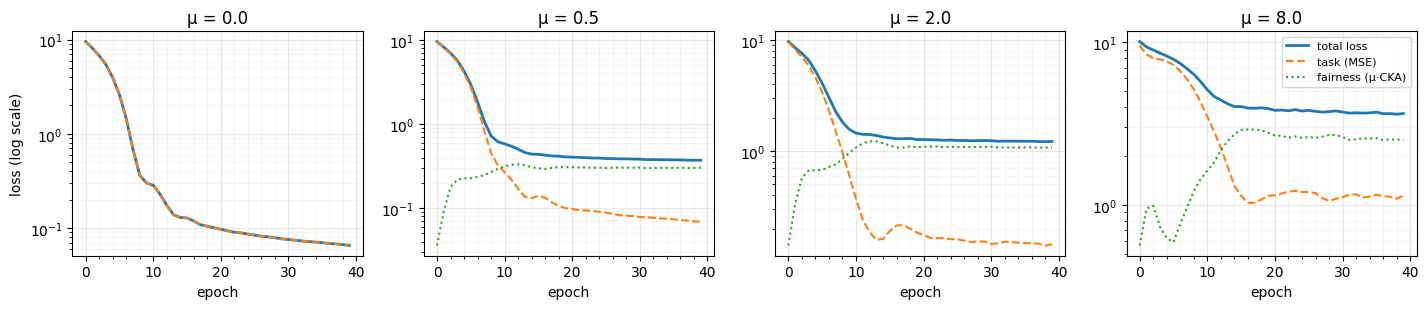

In [5]:
fig, axes = plt.subplots(1, len(mus), figsize=(3.6 * len(mus), 3.2), sharex=True)
for ax, mu in zip(axes, mus, strict=True):
    r = results[mu]
    ax.plot(r["total"], label="total loss", color="tab:blue", lw=2)
    ax.plot(r["task"], label="task (MSE)", color="tab:orange", lw=1.5, ls="--")
    ax.plot(r["fair"], label="fairness (μ·CKA)", color="tab:green", lw=1.5, ls=":")
    ax.set_title(f"μ = {mu}")
    ax.set_xlabel("epoch")
    ax.set_yscale("log")
    style_ax(ax)
axes[0].set_ylabel("loss (log scale)")
axes[-1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**What to notice.** The leftmost panel ($\mu = 0$) is the control: the blue (total) and orange (task) curves are identical, the green (fairness) line sits at zero — nothing to see. Moving right, the fairness term turns on and the story becomes interesting. Early on it dominates the total loss: the freshly-initialised MLP produces predictions that are strongly correlated with `q`, so the CKA term is large and the optimizer prioritises killing it. Over the remaining epochs the two terms trade places — MSE drops as the model fits `y` *using the non-sensitive features*, while the fairness term continues to shrink as `q`-dependence is squeezed out. At $\mu = 8$ the two curves end up roughly equal in magnitude, which is exactly what you would expect when the weights are balanced and the Pareto trade-off is near its hinge.

## The trade-off curve — picking $\mu$ deliberately

The loss curves tell you *what the optimizer is doing*. The held-out trade-off curve tells you *what you are buying*. Each point is one $\mu$, evaluated on the held-out test split: CKA on the x-axis (low is fair), MSE on the y-axis (low is accurate). An ideal model would sit in the bottom-left corner.

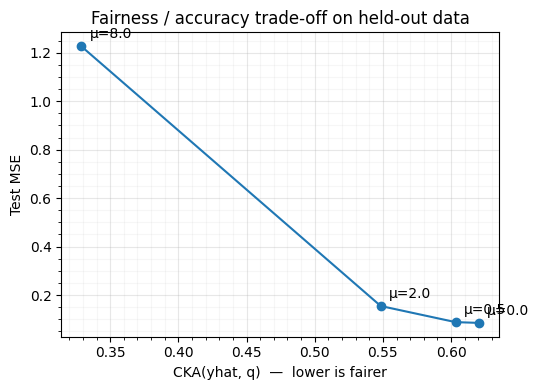

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4))
mses = [results[m]["mse"] for m in mus]
ckas = [results[m]["cka"] for m in mus]
ax.plot(ckas, mses, marker="o", color="tab:blue")
for m, c, e in zip(mus, ckas, mses, strict=True):
    ax.annotate(f"μ={m}", (c, e), textcoords="offset points", xytext=(6, 6))
ax.set_xlabel("CKA(yhat, q)  —  lower is fairer")
ax.set_ylabel("Test MSE")
ax.set_title("Fairness / accuracy trade-off on held-out data")
style_ax(ax)
plt.tight_layout()
plt.show()

**What to notice.** The cost of fairness is *not linear*. The jump from $\mu = 0$ to $\mu = 0.5$ slashes CKA at a very small MSE cost — the first units of fairness are essentially free because the network can satisfy them by reshuffling capacity rather than sacrificing fit. Further along the curve the cost grows: to push CKA below the elbow the model has to truly abandon the `3q` component of the target, and there is no way to recover that information from the other features. This shape is why you cannot pick $\mu$ without looking at a plot — "more fair" is not a linear lever on accuracy.

## Predictions vs. the sensitive attribute

The trade-off curve summarises the pattern. Scatter plots against `q` show you the *mechanism*.

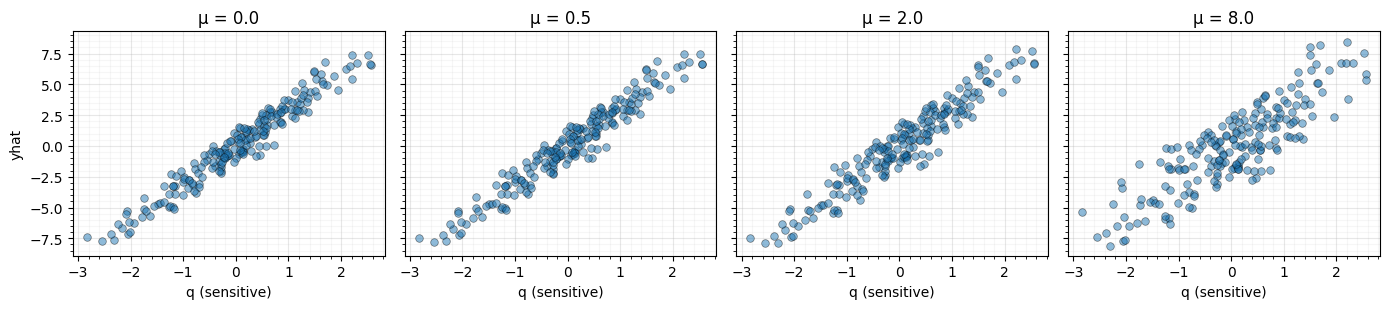

In [7]:
fig, axes = plt.subplots(1, len(mus), figsize=(3.5 * len(mus), 3.2), sharey=True)
for ax, mu in zip(axes, mus, strict=True):
    ax.scatter(qte.ravel(), results[mu]["yh"], color="tab:blue", **SCATTER_KW)
    ax.set_title(f"μ = {mu}")
    ax.set_xlabel("q (sensitive)")
    style_ax(ax)
axes[0].set_ylabel("yhat")
plt.tight_layout()
plt.show()

**What to notice.** At $\mu = 0$ the scatter cloud has a visible positive slope of roughly 3 — exactly the coefficient in the data-generating process. The MLP has faithfully recovered the unfair structure of the world. As $\mu$ grows the cloud rotates toward horizontal: the same `q` value now maps to roughly the same distribution of predictions, which is precisely what independence looks like. By $\mu = 8$ the slope is essentially zero. The model still makes predictions — they are just based on the other features instead.

## One-line swap: CKA → HSIC

`fairness_loss=` is a full-fledged `keras.losses.Loss` slot, not a string or enum. We default to `CKALoss` because its $[0, 1]$ normalisation makes the $\mu$ hyperparameter *scale-invariant* — a given $\mu$ has a comparable effect across datasets of different sizes and feature ranges. But nothing stops you from plugging in `HSICLoss` (unbounded, Gretton's raw kernel HSIC estimator), `MMDLoss` (maximum mean discrepancy, useful when `q` is distributional rather than per-sample), or a custom loss you wrote yourself.

In [8]:
keras.utils.set_random_seed(0)
mlp = build_mlp(d=X.shape[1])
hsic_model = FairModelWrapper(
    mlp, mu=0.2, fairness_loss=HSICLoss(sigma_f=1.0, sigma_q=1.0)
)
hsic_model.compile(optimizer=keras.optimizers.Adam(3e-3), loss="mse")
hsic_model.fit(Xtr, ytr, q=qtr, epochs=20, batch_size=128, verbose=0)

yh = np.asarray(hsic_model.predict(Xte, verbose=0))
mse_h = float(np.mean((yh - yte) ** 2))
cka_h = float(cka_rbf(yh, qte, sigma_f=1.0, sigma_q=1.0))
print(f"HSIC-penalised MLP  |  test MSE = {mse_h:.3f}  |  CKA(yhat, q) = {cka_h:.3f}")

HSIC-penalised MLP  |  test MSE = 0.116  |  CKA(yhat, q) = 0.633


Notice the much smaller $\mu$: HSIC is unbounded, so a $\mu = 0.2$ here is *not* comparable to a $\mu = 0.2$ with `CKALoss`. If you care about portable defaults across datasets, stay with CKA; if you care about the raw dependence signal and are willing to tune $\mu$ per-dataset, HSIC is sharper.

## Searching the hyperparameters — $\mu$ is only one of many

The sweep above fixed every knob except $\mu$: bandwidths at 1, learning rate at $3 \times 10^{-3}$, 40 epochs. Each of those choices quietly shapes the trade-off curve we just plotted. Move the CKA bandwidths by a factor of two and the relative strength of the penalty changes even with $\mu$ held constant. Halve the learning rate and the optimizer may not have time to finish the fairness-vs-accuracy handoff. In short, **there is no one-dimensional trade-off curve** — there is a surface in a four-dimensional space, and the curve we plotted is the silhouette of that surface along the $\mu$ axis for an arbitrary slice of the others.

Random search fixes this cheaply. We define a `keras_tuner.HyperModel` that samples $\mu$, the two CKA bandwidths `sigma_f` and `sigma_q`, and the Adam learning rate. Twenty trials is enough to see the shape of the trade-off surface on this toy problem; on a real dataset you might want hundreds.

This closely mirrors the pattern in [`tutorial_fair_krr_part4.py`](tutorial_fair_krr_part4.py) — the same idea, applied to an arbitrary Keras network rather than kernel ridge regression.

In [9]:
class FairWrapperHyperModel(kt.HyperModel):
    """Random-search space over (mu, sigma_f, sigma_q, lr) for the MLP above."""

    def __init__(self, Xtr, ytr, qtr, Xte, yte, qte):
        super().__init__()
        self.Xtr, self.ytr, self.qtr = Xtr, ytr, qtr
        self.Xte, self.yte, self.qte = Xte, yte, qte

    def build(self, hp):
        mu = hp.Float("mu", min_value=0.0, max_value=10.0, step=0.5)
        sigma_f = hp.Float("sigma_f", min_value=0.2, max_value=5.0, sampling="log")
        sigma_q = hp.Float("sigma_q", min_value=0.2, max_value=5.0, sampling="log")
        keras.utils.set_random_seed(0)
        mlp = build_mlp(d=self.Xtr.shape[1])
        model = FairModelWrapper(
            mlp, mu=mu, fairness_loss=CKALoss(sigma_f=sigma_f, sigma_q=sigma_q)
        )
        lr = hp.Float("lr", min_value=5e-4, max_value=1e-2, sampling="log")
        model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
        return model

    def fit(self, hp, model, *args, **kwargs):
        model.fit(self.Xtr, self.ytr, q=self.qtr, epochs=30, batch_size=128, verbose=0)
        yh = np.asarray(model.predict(self.Xte, verbose=0))
        mse = float(np.mean((yh - self.yte) ** 2))
        cka = float(cka_rbf(yh, self.qte, sigma_f=1.0, sigma_q=1.0))
        return {"val_mse": mse, "val_cka": cka}


hyper = FairWrapperHyperModel(Xtr, ytr, qtr, Xte, yte, qte)
tuner = kt.RandomSearch(
    hyper,
    objective=kt.Objective("val_mse", direction="min"),
    max_trials=20,
    overwrite=True,
    directory="/tmp/fairkl_wrapper_tuning",
    project_name="fair_model_wrapper",
)
tuner.search()

Trial 20 Complete [00h 00m 02s]
val_mse: 1.5061619281768799

Best val_mse So Far: 0.08249792456626892
Total elapsed time: 00h 00m 43s


A couple of design choices are worth calling out. We sample the bandwidths and learning rate *log-uniformly*, because all three are positive scale parameters that span more than an order of magnitude — uniform sampling would crowd the upper end of the range and leave the decade near zero under-explored. The tuner's single scalar objective is `val_mse`; we record `val_cka` as a secondary metric so we can extract the Pareto frontier post-hoc, without forcing the tuner to optimise a weighted combination that would bake in an arbitrary trade-off.

### The sampled trials

Each row is one random hyperparameter draw, sorted by held-out MSE (the tuner's objective). The held-out CKA is recorded alongside so we can read both axes at once.

In [10]:
all_trials = tuner.oracle.get_best_trials(num_trials=20)
rows = []
for t in all_trials:
    hp = t.hyperparameters.values
    rows.append(
        {
            "mu": hp["mu"],
            "sigma_f": hp["sigma_f"],
            "sigma_q": hp["sigma_q"],
            "lr": hp["lr"],
            "val_mse": t.metrics.metrics["val_mse"].get_history()[-1].value[0],
            "val_cka": t.metrics.metrics["val_cka"].get_history()[-1].value[0],
        }
    )

print(
    f"{'rank':>4}  {'mu':>5}  {'sigma_f':>8}  {'sigma_q':>8}  "
    f"{'lr':>8}  {'val_mse':>8}  {'val_cka':>8}"
)
print("-" * 64)
for i, r in enumerate(rows):
    print(
        f"{i + 1:>4}  {r['mu']:>5.2f}  {r['sigma_f']:>8.3f}  {r['sigma_q']:>8.3f}  "
        f"{r['lr']:>8.4f}  {r['val_mse']:>8.3f}  {r['val_cka']:>8.3f}"
    )

rank     mu   sigma_f   sigma_q        lr   val_mse   val_cka
----------------------------------------------------------------
   1   0.00     0.706     0.453    0.0043     0.082     0.622
   2   6.50     0.284     2.607    0.0036     0.130     0.577
   3   0.00     1.483     0.367    0.0011     0.183     0.643
   4   1.50     0.232     0.571    0.0013     0.183     0.602
   5   0.50     2.589     0.581    0.0010     0.219     0.634
   6   9.00     0.322     1.394    0.0060     0.270     0.511
   7   0.00     0.642     0.405    0.0008     0.280     0.647
   8   2.00     0.248     0.469    0.0009     0.314     0.592
   9   5.50     0.276     0.331    0.0071     0.316     0.486
  10   3.00     0.219     0.897    0.0009     0.335     0.586
  11   1.50     0.644     0.359    0.0009     0.339     0.578
  12   4.00     4.700     2.914    0.0022     0.342     0.513
  13   5.50     1.407     1.403    0.0019     0.601     0.450
  14   5.50     1.959     1.121    0.0074     0.916     0.353
  15 

**What to notice.** The best MSE rows are dominated by small $\mu$ (predictable: if you disable the fairness penalty, accuracy improves). But scan the CKA column and an interesting pattern emerges — several mid-table rows with moderate $\mu$ and well-matched bandwidths land at comparable MSE *and* substantially lower CKA than the top-ranked trials. Those are the configurations the MSE-only ranking is hiding. The Pareto plot below surfaces them explicitly.

### The Pareto frontier

A trial is *Pareto-optimal* if no other trial has both lower MSE and lower CKA (with at least one strictly lower). These are the configurations you actually care about: everything else is strictly dominated — some other hyperparameter combination in the sweep beats it on both axes, so there is never a reason to pick it.

11 Pareto-optimal trials out of 20


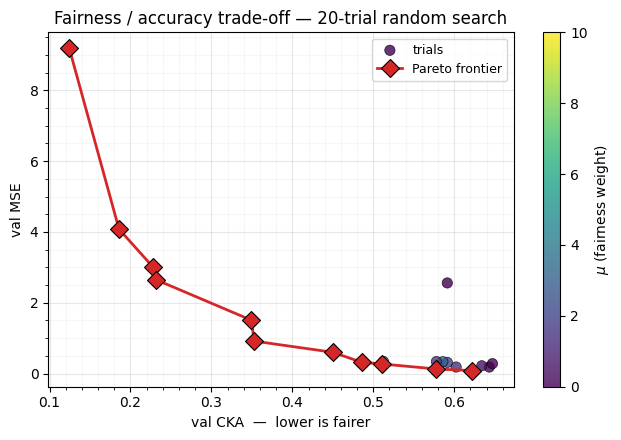

In [11]:
mses_arr = np.array([r["val_mse"] for r in rows])
ckas_arr = np.array([r["val_cka"] for r in rows])
mus_sampled = np.array([r["mu"] for r in rows])

# Pareto filter: a trial is dominated if any other trial has lower (or equal) MSE AND CKA,
# with at least one strict inequality. O(n^2) but trivial for 20 trials.
is_pareto = np.ones(len(rows), dtype=bool)
for i in range(len(rows)):
    for j in range(len(rows)):
        if (
            i != j
            and mses_arr[j] <= mses_arr[i]
            and ckas_arr[j] <= ckas_arr[i]
            and (mses_arr[j] < mses_arr[i] or ckas_arr[j] < ckas_arr[i])
        ):
            is_pareto[i] = False
            break
pareto_idx = np.where(is_pareto)[0]
order = np.argsort(ckas_arr[pareto_idx])
p_ckas = ckas_arr[pareto_idx][order]
p_mses = mses_arr[pareto_idx][order]
print(f"{is_pareto.sum()} Pareto-optimal trials out of {len(rows)}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sc = ax.scatter(
    ckas_arr,
    mses_arr,
    c=mus_sampled,
    cmap="viridis",
    s=55,
    edgecolors="k",
    linewidths=0.5,
    alpha=0.8,
    zorder=3,
    label="trials",
)
plt.colorbar(sc, ax=ax, label=r"$\mu$ (fairness weight)")
ax.plot(
    p_ckas,
    p_mses,
    "D-",
    color="C3",
    lw=2,
    markersize=9,
    markeredgecolor="k",
    markeredgewidth=0.8,
    zorder=5,
    label="Pareto frontier",
)
ax.set_xlabel("val CKA  —  lower is fairer")
ax.set_ylabel("val MSE")
ax.set_title("Fairness / accuracy trade-off — 20-trial random search")
ax.legend(fontsize=9)
style_ax(ax)
plt.tight_layout()
plt.show()

**What to notice.** Compare this plot to the four-point trade-off curve earlier. That earlier curve is a specific *path* through this surface — a path along which all hyperparameters except $\mu$ were pinned at one arbitrary choice. The scatter here makes it visible that many configurations with the same colour (same $\mu$) land in wildly different places because their bandwidths and learning rates are different. The red Pareto frontier is what you were really after all along: the set of trade-offs you cannot improve on simultaneously, given the capacity of the architecture and the budget of the search.

The practical recipe: run the tuner, read the frontier, pick the point that matches your fairness tolerance, and retrain that configuration to deploy. That is a workflow that composes cleanly with anything Keras supports — callbacks, mixed precision, `tf.data` pipelines, multi-device training — because the wrapper never steps outside the standard API.